<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/TugasKelompok_DBscan_murl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Wawa Elent Irawanti

**NIM:** 244107020192

**Kelas:** TI-3H

**1. Import library**

In [2]:
import pandas as pd
import numpy as np
import re

from urllib.parse import urlparse

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**2. Baca dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Malicious URL Detection.csv to Malicious URL Detection.csv


In [4]:
df = pd.read_csv("Malicious URL Detection.csv")

print("Shape dataset:", df.shape)
print("\nKolom:")
print(df.columns.tolist())

df.head()

Shape dataset: (783705, 2)

Kolom:
['url', 'type']


,url,type
0,mp3raid.com/music/krizz_kaliko.html,benign
1,bopsecrets.org/rexroth/cr/1.htm,benign
2,buzzfil.net/m/show-art/ils-etaient-loin-de-s-i...,benign
3,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
4,yourbittorrent.com/?q=anthony-hamilton-soulife,benign


**3. Membuat fungsi ekstraksi fitur URL**

In [5]:
def extract_url_features(url):
    url = str(url)

    domain = ""
    path = ""

    try:
        parsed = urlparse(
            url if re.match(r"^[a-zA-Z]+://", url) else "//" + url
        )

        domain = parsed.netloc
        path = parsed.path

    except ValueError:
        domain = ""
        path = url

    features = {
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "num_digits": sum(c.isdigit() for c in url),
        "num_letters": sum(c.isalpha() for c in url),
        "num_dots": url.count("."),
        "num_slashes": url.count("/"),
        "num_hyphens": url.count("-"),
        "num_underscores": url.count("_"),
        "num_question_marks": url.count("?"),
        "num_equal": url.count("="),
        "num_ampersand": url.count("&"),
        "num_special_chars": sum(not c.isalnum() for c in url),
        "num_subdomains": max(domain.count(".") - 1, 0),
        "has_ip": int(bool(
            re.match(r"^(?:\d{1,3}\.){3}\d{1,3}$", domain)
        )),
        "has_https": int(url.lower().startswith("https://"))
    }

    return features

**4. Membuat fitur URL**

In [ ]:
import re
from urllib.parse import urlparse

# Mengubah URL menjadi beberapa fitur angka
def extract_url_features(url):
    url = str(url)

    # Menyiapkan domain dan path
    domain = ""
    path = ""

    try:
        # Memisahkan URL menjadi bagian domain dan path
        parsed = urlparse(
            url if re.match(r"^[a-zA-Z]+://", url) else "//" + url
        )

        domain = parsed.netloc
        path = parsed.path

    except ValueError:
        # Jika URL rusak, URL tetap digunakan untuk mengambil fitur
        domain = ""
        path = url

    features = {
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "num_digits": sum(c.isdigit() for c in url),
        "num_letters": sum(c.isalpha() for c in url),
        "num_dots": url.count("."),
        "num_slashes": url.count("/"),
        "num_hyphens": url.count("-"),
        "num_underscores": url.count("_"),
        "num_question_marks": url.count("?"),
        "num_equal": url.count("="),
        "num_ampersand": url.count("&"),
        "num_special_chars": sum(
            not c.isalnum() for c in url
        ),
        "num_subdomains": max(domain.count(".") - 1, 0),
        "has_ip": int(
            bool(
                re.match(
                    r"^(?:\d{1,3}\.){3}\d{1,3}$",
                    domain
                )
            )
        ),
        "has_https": int(
            url.lower().startswith("https://")
        )
    }

    return features

**5. Membuat tabel fitur**

In [6]:
# Mengambil fitur dari setiap URL
features = df["url"].apply(extract_url_features)

# Membuat tabel fitur
X = pd.DataFrame(features.tolist())

# Menyimpan jenis URL
y = df["type"]

print("Shape X:", X.shape)

X.head()

Shape X: (783705, 16)


,url_length,domain_length,path_length,num_digits,num_letters,num_dots,num_slashes,num_hyphens,num_underscores,num_question_marks,num_equal,num_ampersand,num_special_chars,num_subdomains,has_ip,has_https
0,35,11,24,1,29,2,2,0,1,0,0,0,5,0,0,0
1,31,14,17,1,25,2,3,0,0,0,0,0,5,0,0,0
2,111,11,100,1,89,2,3,16,0,0,0,0,21,0,0,0
3,45,11,34,4,31,2,6,1,1,0,0,0,10,1,0,0
4,46,18,1,0,40,1,1,2,0,1,1,0,6,0,0,0


**6. Cek data kosong**

In [7]:
print("Missing values:")
print(X.isna().sum())

Missing values:
url_length            0
domain_length         0
path_length           0
num_digits            0
num_letters           0
num_dots              0
num_slashes           0
num_hyphens           0
num_underscores       0
num_question_marks    0
num_equal             0
num_ampersand         0
num_special_chars     0
num_subdomains        0
has_ip                0
has_https             0
dtype: int64


**7. Standarisasi fitur**

In [8]:
# Menyamakan skala nilai setiap fitur
scaler = StandardScaler()

# Melakukan standardisasi pada data fitur
X_scaled = scaler.fit_transform(X)

print("Shape X_scaled:", X_scaled.shape)

Shape X_scaled: (783705, 16)


**8. Mengambil sampel 10.000 data**

In [9]:
# Menentukan jumlah data yang digunakan
sample_size = 10000

# Membuat pengambilan data secara acak tetapi tetap
rng = np.random.RandomState(42)

# Mengambil 10.000 data secara acak
sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

# Mengambil fitur dari data sampel
X_sample = X_scaled[sample_indices]

# Mengambil jenis URL dari data sampel
y_sample = y.iloc[sample_indices].reset_index(drop=True)

print("Sample shape:", X_sample.shape)

Sample shape: (10000, 16)


**9. Menentukan kandidat eps dengan K-Distance Plot**

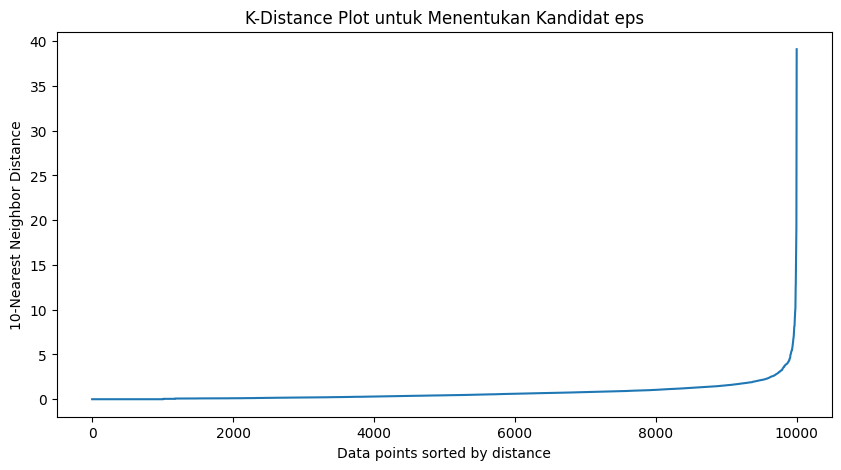

In [10]:
# Menentukan jumlah tetangga
min_samples = 10

# Mencari 10 tetangga terdekat
neighbors = NearestNeighbors(
    n_neighbors=min_samples,
    n_jobs=-1
)

# Menggunakan data sampel
neighbors.fit(X_sample)

# Menghitung jarak ke tetangga
distances, indices = neighbors.kneighbors(X_sample)

# Mengurutkan jarak
k_distances = np.sort(distances[:, -1])

# Membuat grafik K-Distance
plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Data points sorted by distance")
plt.ylabel(f"{min_samples}-Nearest Neighbor Distance")
plt.title("K-Distance Plot untuk Menentukan Kandidat eps")

plt.show()

**10. Menjalankan DBSCAN**

In [11]:
# Menentukan parameter DBSCAN
eps = 1.0
min_samples = 10

# Membuat model DBSCAN
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    n_jobs=-1
)

# Menentukan cluster untuk setiap data
dbscan_labels = dbscan.fit_predict(X_sample)

**11. Menghitung jumlah cluster dan noise**

In [12]:
# Mengambil semua label cluster
unique_labels = set(dbscan_labels)

# Menghitung jumlah cluster tanpa noise
n_clusters = len(unique_labels - {-1})

# Menghitung jumlah data yang dianggap noise
n_noise = np.sum(dbscan_labels == -1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)
print("Persentase noise:", n_noise / len(dbscan_labels) * 100, "%")

Jumlah cluster: 21
Jumlah noise: 1633
Persentase noise: 16.33 %


**12. Melihat jumlah data setiap cluster**

In [13]:
# Menghitung jumlah data pada setiap cluster
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()

print(cluster_counts)

-1     1633
 0     1910
 1     4856
 2       29
 3      519
 4       43
 5      133
 6       59
 7      125
 8      158
 9       42
 10     222
 11      25
 12      19
 13     122
 14      14
 15      20
 16      11
 17      12
 18      23
 19      15
 20      10
Name: count, dtype: int64


**13. Grafik distribusi data per cluster**

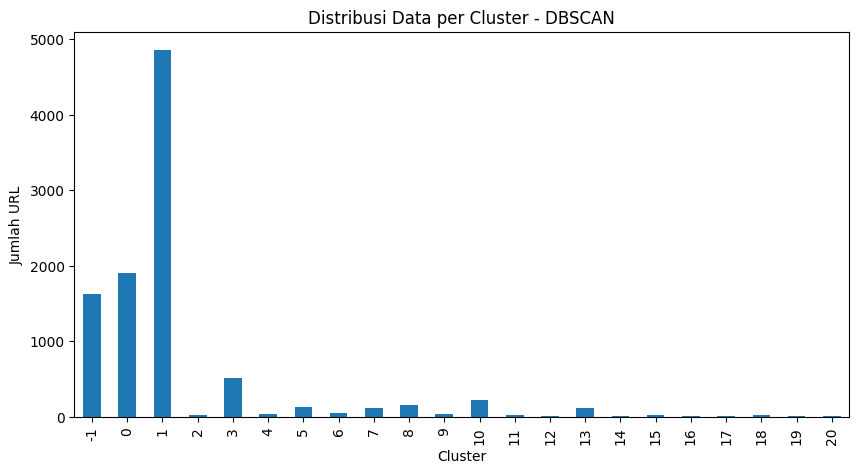

In [15]:
plt.figure(figsize=(10, 5))

# Menampilkan jumlah data pada setiap cluster
cluster_counts.plot(kind="bar")

plt.title("Distribusi Data per Cluster - DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Jumlah URL")

plt.show()

**14. Menghitung Silhouette Score**

In [14]:
# Mengambil data yang bukan noise
non_noise_mask = dbscan_labels != -1

X_non_noise = X_sample[non_noise_mask]
labels_non_noise = dbscan_labels[non_noise_mask]

# Menghitung jumlah cluster tanpa noise
n_clusters_non_noise = len(set(labels_non_noise))

if n_clusters_non_noise >= 2:
    # Menghitung Silhouette Score
    silhouette = silhouette_score(
        X_non_noise,
        labels_non_noise
    )

    print(f"Silhouette Score (non-noise): {silhouette:.4f}")

else:
    print("Silhouette Score tidak dapat dihitung.")
    print("Jumlah cluster non-noise kurang dari 2.")

Silhouette Score (non-noise): 0.1458


**15. PCA untuk visualisasi**

In [16]:
# Mengubah 16 fitur menjadi 2 fitur
pca = PCA(n_components=2, random_state=42)

# Mengubah data menjadi 2 dimensi
X_pca = pca.fit_transform(X_sample)

# Melihat informasi yang dipertahankan
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.3216554  0.16071169]
Total explained variance: 0.48236708327648076


**16. Membuat grafik hasil DBSCAN**

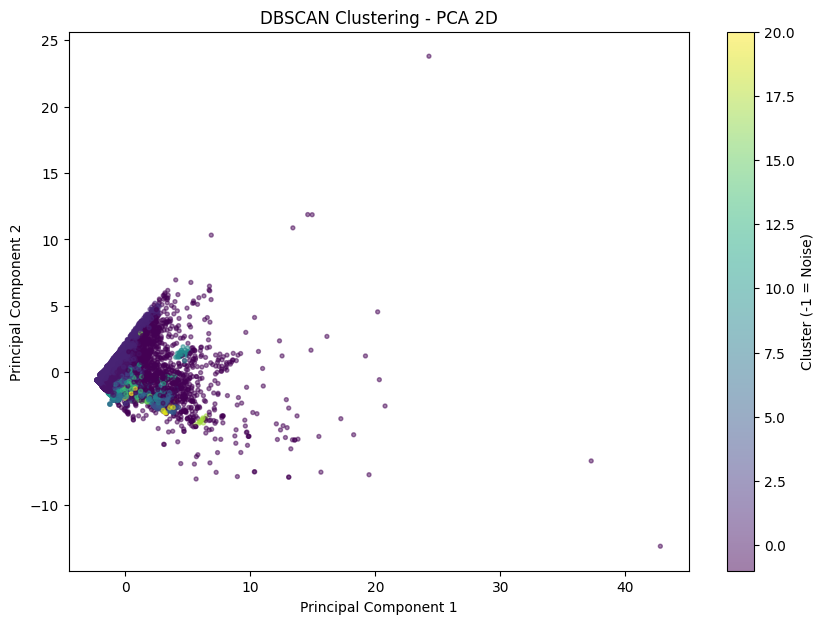

In [17]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.5
)

plt.title("DBSCAN Clustering - PCA 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="Cluster (-1 = Noise)"
)

plt.show()

**17. Melihat hubungan cluster dengan jenis URL**

In [18]:
# Membuat tabel jenis URL dan hasil cluster
visual_df = pd.DataFrame({
    "type": y_sample,
    "cluster": dbscan_labels
})

# Membuat tabel jumlah jenis URL pada setiap cluster
cross_tab = pd.crosstab(
    visual_df["cluster"],
    visual_df["type"]
)

cross_tab

type,Exploit,benign,defacement,legitimate,malware,phishing,spam
cluster,,,,,,,
-1,0,899,227,0,42,461,4
0,0,947,81,13,45,817,7
1,0,2965,400,56,67,1352,16
2,0,0,0,0,0,29,0
3,0,345,73,0,0,101,0
4,0,0,42,0,0,1,0
5,0,1,131,0,1,0,0
6,0,18,35,0,6,0,0
7,2,0,0,0,93,30,0
